In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
uploaded=files.upload()


Saving mobility_services.csv to mobility_services.csv


In [ ]:
'''1.
timestamp(Interval): We can find differences between time stamps but cannot say there is a true zero point
average_fare(Ratio): Average fare represents a continuous numeric value with a meaningful zero point (a fare of zero means no charge). It allows for operations like multiplication and division, making it a ratio variable.
rides_completed(Ratio)This is a count of completed rides, which has a true zero point (0 rides completed means no rides were completed) and supports ratio comparisons (e.g., twice as many rides).
driver_availability(Ratio)Driver availability is expressed as a percentage, which inherently has a meaningful zero (0% means no drivers available) and can be multiplied, divided, etc. This makes it a ratio variable.
surge_multiplier(Ratio): Surge multiplier has a true zero (no multiplier effect) and supports ratio calculations (e.g., a 2x multiplier doubles the fare). Thus, it’s classified as a ratio variable.
vehicle_type(Nominal): Vehicles only have categories
weather(Nominal): Weather only has categories
traffic_index(Interval): They can be compared but you can’t specifically say that some amount of traffic on the index is twice as big as each other
special_event(Nominal): Has 2 categories, 0 and 1.'''

In [ ]:
''' 2.There are a lot of missing values.
For the field of timestamp, just a simple forward fill will suffice, where each missing value is filled with the last non-missing value
For the fields of rides completed and traffic index, we use the mean of all non missing values to replace the blank fields
For the surge multiplier field we use the median, to be able to ignore the outliers that exist
For special event we fill in all blank values as 0
For vehicle type, we drop all blank values'''


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('mobility_services.csv')
df[['timestamp']] = df[['timestamp']].ffill()
df['rides_completed'] = df['rides_completed'].fillna(df['rides_completed'].mean())
df['surge_multiplier'] = df['surge_multiplier'].fillna(df['surge_multiplier'].median())
df['traffic_index'] = df['traffic_index'].fillna(df['traffic_index'].mean())
df['special_event'] = df['special_event'].replace(np.nan, 0)
df.dropna(subset=['vehicle_type'], inplace=True)
df.reset_index(drop=True, inplace=True)
duplicates = df[df.duplicated()]
df.drop_duplicates(inplace=True)

#3.
df.describe()

,average_fare,rides_completed,driver_availability,surge_multiplier,traffic_index,special_event
count,52419.000000,52419.000000,52419.000000,52419.000000,52419.000000,52419.000000
mean,70.114636,378.224921,44.673456,1.245730,59.579176,0.078292
std,39.424347,265.800191,15.291298,0.227851,20.310688,0.268633
min,20.000000,10.000000,30.000000,1.000000,20.000000,0.000000
25%,40.000000,180.000000,30.000000,1.000000,46.000000,0.000000
50%,47.482059,377.249186,40.470136,1.215388,59.504437,0.000000
75%,105.980207,470.000000,54.132897,1.303691,74.000000,0.000000
max,161.232316,2546.000000,100.000000,3.400358,99.000000,1.000000


In [ ]:
for column in df.select_dtypes(include=[np.number]).columns:  
    print(f"Median of {column}: {df[column].median()}")
    
    '''Median of average_fare: 47.48205928405509
Median of rides_completed: 377.2491861252954
Median of driver_availability: 40.47013624926891
Median of surge_multiplier: 1.2153881546943648
Median of traffic_index: 59.50443706311041
Median of special_event: 0.0

For all numerical values, except surge multiplier and special event, the mean is the best indicator of central tendency. 
For the previously mentioned two, the median is a better indicator
'''

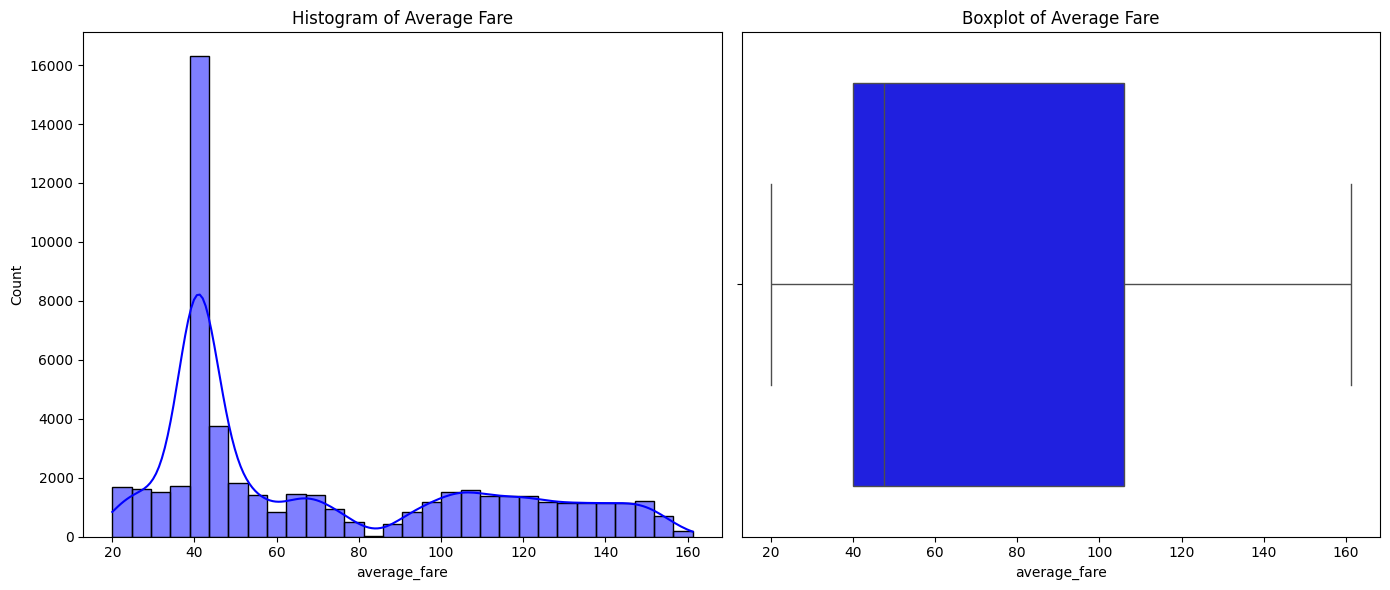

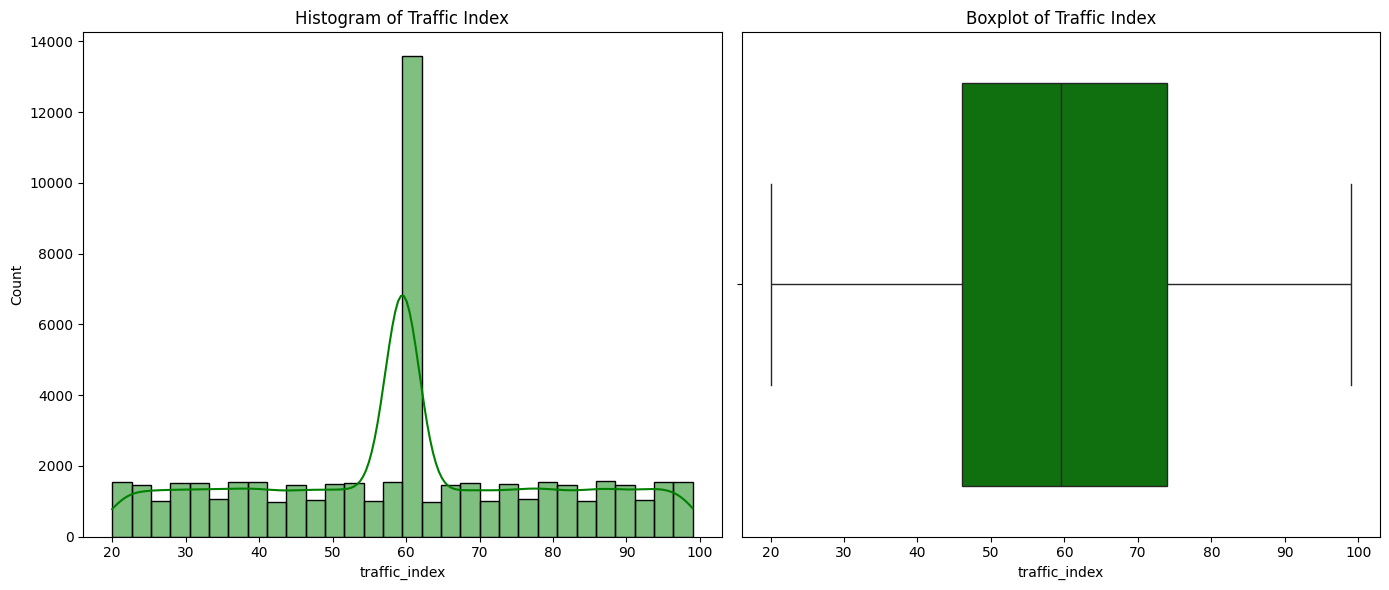

In [ ]:
'''4'''
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['average_fare'], kde=True, bins=30, color='blue')
plt.title('Histogram of Average Fare')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['average_fare'], color='blue')
plt.title('Boxplot of Average Fare')
plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['traffic_index'], kde=True, bins=30, color='green')
plt.title('Histogram of Traffic Index')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['traffic_index'], color='green')
plt.title('Boxplot of Traffic Index')
plt.tight_layout()
plt.show()

In [ ]:
'''5.We use the IQR(Inter Quartile Range) method to remove outliers.We take the IQR value as the difference between 
the 1st Quartile(Q1) and 3rd Quartile(Q3). Any values that exist outside of the range (Q1 - 1.5IQR, Q3 + 1.5IQR)
 is taken as an outlier and removed to improve the quality of our data.
'''

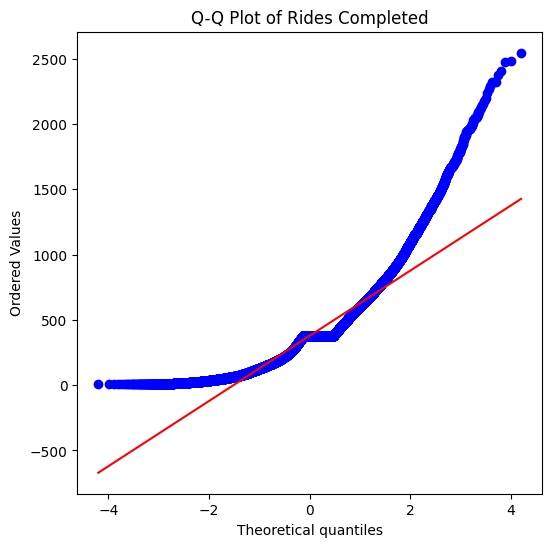

In [ ]:
'''6'''
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(df['rides_completed'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Rides Completed')
plt.show()


In [ ]:
'''We can see that our data is right skewed and does not fit with the alignment required of a normal distribution. '''

In [ ]:
'''7'''
numeric_df = df.select_dtypes(include=[float, int])
correlation_matrix = numeric_df.corr()
print(correlation_matrix)
if 'driver_availability' in correlation_matrix.columns:
    correlations_with_driver_availability = correlation_matrix['driver_availability']
    highest_correlation_variable = correlations_with_driver_availability.drop('driver_availability').idxmax()
    highest_correlation_value = correlations_with_driver_availability.drop('driver_availability').max()
    print(f"The variable with the highest correlation with 'driver_availability' is '{highest_correlation_variable}' with a correlation of {highest_correlation_value:.2f}")
else:
    print("The 'driver_availability' column is not in the correlation matrix.")


                     average_fare  rides_completed  driver_availability  \
average_fare             1.000000        -0.559743            -0.422799   
rides_completed         -0.559743         1.000000             0.583190   
driver_availability     -0.422799         0.583190             1.000000   
surge_multiplier        -0.023479         0.038291             0.028415   
traffic_index            0.000218        -0.243537            -0.176731   
special_event           -0.007874         0.008490             0.010490   

                     surge_multiplier  traffic_index  special_event  
average_fare                -0.023479       0.000218      -0.007874  
rides_completed              0.038291      -0.243537       0.008490  
driver_availability          0.028415      -0.176731       0.010490  
surge_multiplier             1.000000       0.350411       0.473995  
traffic_index                0.350411       1.000000      -0.002521  
special_event                0.473995      -0.002521  

In [ ]:
'''As we can see the driver availability has the highest correlation with ride completion'''

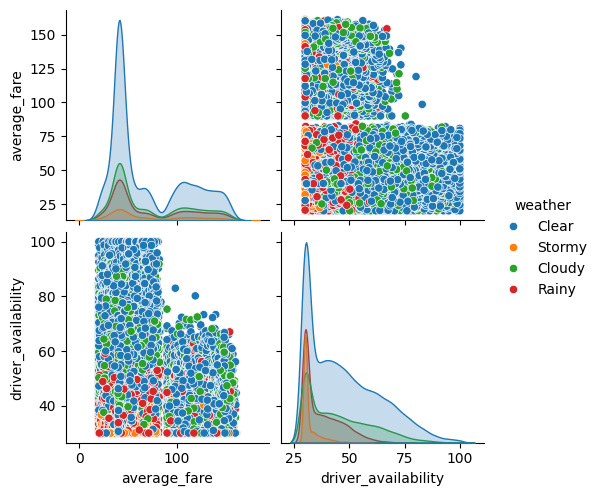

In [ ]:
'''8'''
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df[['average_fare', 'driver_availability', 'vehicle_type', 'weather']], hue='weather')
plt.show()


T-statistic: -391.96
P-value: 0.0000
Reject the null hypothesis: There is a significant difference in the average fare paid between bikes and cars.


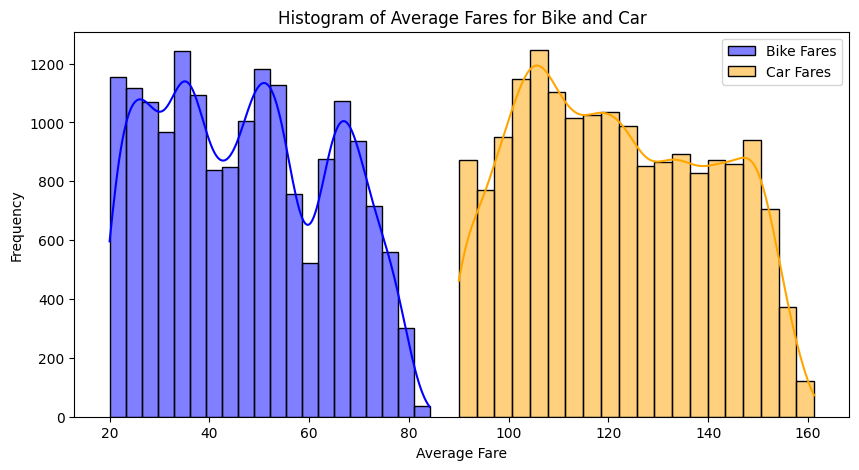

In [ ]:
'''9'''
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
bike_fares = df[df['vehicle_type'] == 'bike']['average_fare']
car_fares = df[df['vehicle_type'] == 'car']['average_fare']
t_stat, p_value = stats.ttest_ind(bike_fares, car_fares, equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in the average fare paid between bikes and cars.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the average fare paid between bikes and cars.")
plt.figure(figsize=(10, 5))
sns.histplot(bike_fares, bins=20, color='blue', label='Bike Fares', kde=True)
sns.histplot(car_fares, bins=20, color='orange', label='Car Fares', kde=True)
plt.title('Histogram of Average Fares for Bike and Car')
plt.xlabel('Average Fare')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [ ]:
'''10'''
from scipy import stats
mean_bike = np.mean(bike_fares)
mean_car = np.mean(car_fares)
std_bike = np.std(bike_fares, ddof=1)
std_car = np.std(car_fares, ddof=1)
n_bike = len(bike_fares)
n_car = len(car_fares)
SE = np.sqrt((std_bike**2 / n_bike) + (std_car**2 / n_car))
z = 1.96
MoE = z * SE
print("Margin of Error: {MoE:.2f}")
mean_diff = mean_bike - mean_car
conf_interval = (mean_diff - MoE, mean_diff + MoE)
print("95% Confidence Interval for the difference in means: {conf_interval}")


Margin of Error: 0.37
95% Confidence Interval for the difference in means: (-74.97197565630978, -74.22591774190818)


Mean Squared Error (MSE): 34761.479037845675
Root Mean Squared Error (RMSE): 186.44430545834774
R-squared (R²): 0.5010780915434144


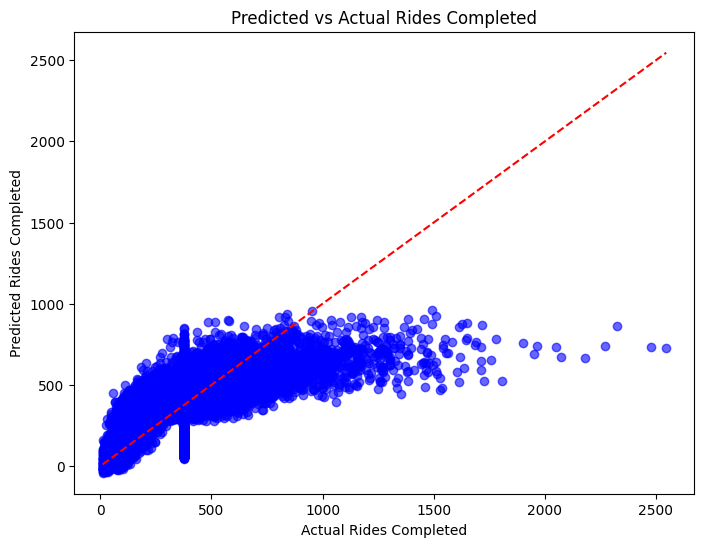

In [ ]:
'''11'''
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


X = df[['average_fare', 'driver_availability', 'surge_multiplier', 'traffic_index', 'special_event']]
y = df['rides_completed']

if X.isnull().sum().any() or y.isnull().sum() > 0:
    raise ValueError("There are still missing values in X or y. Please clean the data.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R²): {r2}')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Predicted vs Actual Rides Completed')
plt.xlabel('Actual Rides Completed')
plt.ylabel('Predicted Rides Completed')
plt.show()


In [ ]:
'''12.
Adding data on ride duration, distance covered, and location will enhance analysis to a great extent. 
Ride duration helps understand the fare structure, driver efficiency, and traffic conditions. Distance covered is 
crucial for fare calculation and cost estimation, impacting driver workload and fuel consumption. Location data 
identifies high-demand areas, aids in demand prediction, and supports surge pricing decisions. Combined, these 
metrics allow for better operational planning, route optimization, and customer satisfaction improvements.
'''